# 06 Hardware and Noise

Going in depth on the real hardware device and noise simulation

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg
import networkx as nx

## Noise

Channels: individual noisy op 

NoiseModel: apply noise to the circuit 

MeasurmentGate: parameters chanign the measuremente result (readout errors)

#### Channel 

bit-flip example

In [49]:
q0 = cirq.LineQubit(0)
circuit = cirq.Circuit(cirq.bit_flip(p=0.02).on(q0), cirq.measure(q0, key='result'))
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
print(result.histogram(key='result'))

Counter({0: 973, 1: 27})


Amplitude damping $T_1$ $|1\rangle \to |0\rangle$ 

In [50]:
q0 = cirq.LineQubit(0)
circuit = cirq.Circuit(
    cirq.X(q0), cirq.amplitude_damp(gamma=0.2).on(q0), cirq.measure(q0, key='result')
)
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
print(result.histogram(key='result'))

Counter({1: 795, 0: 205})


Probability of decaying is $\gamma = 1 - e^{-\tau/T_1}$, where $\tau$ is the actual time of the gate.

Generalized damping (Finitite temperature). Including spontaneoius excitation. 

Excites with prob $(1-p)\gamma$ and decays with prob $p\gamma$

In [51]:
q0, q1 = cirq.LineQubit.range(2)
circuit = cirq.Circuit(
    cirq.X(q1),
    cirq.generalized_amplitude_damp(gamma=0.2, p=0.2).on_each(q0, q1),
    cirq.measure(q0, key='result_0'),
    cirq.measure(q1, key='result_1'),
)
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
print("Starting in |0):", result.histogram(key='result_0'))
print("Starting in |1):", result.histogram(key='result_1'))

Starting in |0): Counter({0: 824, 1: 176})
Starting in |1): Counter({1: 956, 0: 44})


Phase flip or damping

In [52]:
q0 = cirq.LineQubit(0)
circuit = cirq.Circuit(
    cirq.H(q0), cirq.phase_flip(p=0.2).on(q0), cirq.H(q0), cirq.measure(q0, key='result')
)
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
print("Phase flip:", result.histogram(key='result'))

Phase flip: Counter({0: 795, 1: 205})


damping is the same idea but relates to $\gamma = 1 - (2p - 1)^2$

$T_2$ coherence decay time. $\rho_{01} \to e^{-\tau/T_2}\rho_{01}$. From a phase-flip channel $\rho_{01} \to (1-2p)\rho_{01}$.

$$
1 - 2p_{\phi} = e^{-\tau/T_\phi}
$$
where $T_\phi$ is the pure dephasing time. 

Then, $ e^{-\tau/T_2} =  e^{-\tau/(2T_1)} e^{-\tau/T_\phi}$, because bit flip also influence coherence. 

In [53]:
q0 = cirq.LineQubit(0)
# Convert p=0.2 to gamma
p = 0.2
gamma = 1 - (2 * p - 1) ** 2
print(f"{gamma=}")
circuit = cirq.Circuit(
    cirq.H(q0), cirq.phase_damp(gamma=gamma).on(q0), cirq.H(q0), cirq.measure(q0, key='result')
)
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
print("Phase damp:", result.histogram(key='result'))

gamma=0.64
Phase damp: Counter({0: 777, 1: 223})


Depolarization: $1-p$ Identity or $p/(4^n - 1)$ for  X,Y,Z

In [54]:
q0, q1, q2 = cirq.LineQubit.range(3)
circuit = cirq.Circuit(
    cirq.H(q0),  # initialize X basis
    cirq.H(q1),  # initialize Y basis
    cirq.S(q1),
    cirq.depolarize(p=0.2).on_each(q0, q1, q2),
    cirq.H(q0),  # return to Z-basis
    cirq.S(q1) ** -1,
    cirq.H(q1),
    cirq.measure(q0, key='result_0'),
    cirq.measure(q1, key='result_1'),
    cirq.measure(q2, key='result_2'),
)
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
# All basis states are equally affected.
print("X basis:", result.histogram(key='result_0'))
print("Y basis:", result.histogram(key='result_1'))
print("Z basis:", result.histogram(key='result_2'))


X basis: Counter({0: 872, 1: 128})
Y basis: Counter({0: 862, 1: 138})
Z basis: Counter({0: 892, 1: 108})


Asymmetric depolarization

In [55]:
q0, q1, q2 = cirq.LineQubit.range(3)
asym_depol = cirq.asymmetric_depolarize(p_x=0, p_y=0.05, p_z=0.2)
circuit = cirq.Circuit(
    cirq.H(q0),  # initialize X basis
    cirq.H(q1),  # initialize Y basis
    cirq.S(q1),
    asym_depol.on_each(q0, q1, q2),
    cirq.H(q0),  # return to Z-basis
    cirq.S(q1) ** -1,
    cirq.H(q1),
    cirq.measure(q0, key='result_0'),
    cirq.measure(q1, key='result_1'),
    cirq.measure(q2, key='result_2'),
)
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
# Basis states are only affected by error in other bases.
print("X basis:", result.histogram(key='result_0'))
print("Y basis:", result.histogram(key='result_1'))
print("Z basis:", result.histogram(key='result_2'))

X basis: Counter({0: 764, 1: 236})
Y basis: Counter({0: 800, 1: 200})
Z basis: Counter({0: 950, 1: 50})


Reset

In [56]:
q0 = cirq.LineQubit(0)
circuit = cirq.Circuit(cirq.bit_flip(p=0.2).on(q0), cirq.reset(q0), cirq.measure(q0, key='result'))
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
print(result.histogram(key='result'))

Counter({0: 1000})


Custom Channels: probabilistic mixture of unitary op. 

In [57]:
q0 = cirq.LineQubit(0)
# equivalent to cirq.bit_flip(p=0.2)
my_channel = cirq.MixedUnitaryChannel(
    [(0.8, cirq.unitary(cirq.I)), (0.2, cirq.unitary(cirq.X))], key='op_num'
)
circuit = cirq.Circuit(my_channel.on(q0), cirq.measure(q0, key='result'))
result = cirq.Simulator(seed=0).run(circuit, repetitions=20)
# `op_num` and `result` are always equal.
print(result)

op_num=00001000001000000001
result=00001000001000000001


Kraus Channel similar to the Custom but support non-unitary op. 

In [59]:

q0 = cirq.LineQubit(0)
# equivalent to cirq.amplitude_damp(gamma=0.2)
gamma = 0.2
my_channel = cirq.KrausChannel(
    [
        np.array([[0, np.sqrt(gamma)], [0, 0]]),  # decay |1) -> |0)
        np.array([[1, 0], [0, np.sqrt(1 - gamma)]]),  # stay in |1)
    ],
    key='op_num',
)
circuit = cirq.Circuit(cirq.X(q0), my_channel.on(q0), cirq.measure(q0, key='result'))
result = cirq.Simulator(seed=0).run(circuit, repetitions=20)
# `op_num` and `result` are always equal.
print(result)

op_num=11111110011100111011
result=11111110011100111011


#### Noise models 

Constant noise (not very representative to real hardware but better than noiseless)

In [62]:
q0 = cirq.LineQubit(0)
circuit = cirq.Circuit(
    cirq.I(q0), cirq.measure(q0, key='result_0'), cirq.measure(q0, key='result_1')
)
# Applies noise after every gate, even measurements.
noisy_circuit = circuit.with_noise(cirq.X)
print(noisy_circuit)
result = cirq.Simulator(seed=0).run(noisy_circuit, repetitions=1000)
print("First measure:", result.histogram(key='result_0'))
print("Second measure:", result.histogram(key='result_1'))

0: ───I───X[<virtual>]───M('result_0')───X[<virtual>]───M('result_1')───X[<virtual>]───
First measure: Counter({1: 1000})
Second measure: Counter({0: 1000})


Insertion noise: givs extra freedom to insert different noises for user-specified intendifiers. 

Ex: Bit-flip with p = 0.2 after each X gate

In [64]:
from cirq.devices import InsertionNoiseModel

q0 = cirq.LineQubit(0)
circuit = cirq.Circuit(cirq.I(q0), cirq.X(q0), cirq.measure(q0, key='result'))
# Apply bitflip noise after each X gate.
target_op = cirq.OpIdentifier(cirq.XPowGate, q0)
insert_op = cirq.bit_flip(p=0.2).on(q0)
noise_model = InsertionNoiseModel(
    ops_added={target_op: insert_op},
    require_physical_tag=False,  # For use outside calibration-to-noise
)
noisy_circuit = circuit.with_noise(noise_model)
print(noisy_circuit)
result = cirq.Simulator(seed=0).run(noisy_circuit, repetitions=1000)
print(result.histogram(key='result'))

0: ───I───X───BF(0.2)───M('result')───
Counter({1: 795, 0: 205})


#### Measurement

Invert mask: indicates which bits should be flipped in the final output

In [65]:
q0 = cirq.LineQubit(0)
circuit = cirq.Circuit(cirq.X(q0), cirq.measure(q0, key='result', invert_mask=[True]))
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
print(result.histogram(key='result'))

Counter({0: 1000})


Confusion map: maps qubit tuples to confusion matrices. Ex: Pr(observed bitstring/ true bit string)

For two qubits:
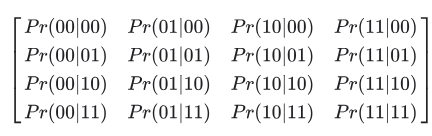

In [68]:
# 1% chance to report |0) as |1), 3% chance to report |1) as |0).
confusion = {
    (0,): np.array([
        [0.99, 0.01],
        [0.03, 0.97],
    ])
}

q0 = cirq.LineQubit(0)
circuit = cirq.Circuit(cirq.X(q0), cirq.measure(q0, key='result', confusion_map=confusion))
result = cirq.Simulator(seed=0).run(circuit, repetitions=1000)
print(result.histogram(key='result'))


Counter({1: 967, 0: 33})


### Cross-Entropy Benchmarking (XEB) Theory 

Suppose $U$ is a random circuit, the state is $|\psi_U\rangle =  U|0\dots 0\rangle$ and the prob $p_U(x) =|\langle x | \psi_U\rangle|^2$ for every bitstring $x$. 

XEB asks: is the bitstring following $p_U(x)$ better than random bitstrings (uniform for depolarization).

$f \approx 1$ (perfect) and $f \approx 0 $ (fully scrambled into uniform noise)

$\rho_U = f |\psi_U\rangle\langle\psi_U| + (1-f)\frac{I}{D}$, where $f$ is the fidelity, $D$ is the Hilbert-space dimension, $I/D$ means maximally mixed state. This effective model works when the noise in the circuit are stochastic and after many random samples it acts as depolarization. 

To estimate the fidelity we pick an observable $O_U$ in the computational basis
$$
Tr(\rho_U O_U ) = f \langle\psi_U|O_U|\psi_U\rangle + (1-f)Tr(O_U/D) \\
m_U = f e_U + (1-f)u_U
$$
where $m_U = Tr(\rho_U O_U )$, $e_U = \langle\psi_U|O_U|\psi_U\rangle$, and $u_U = Tr(O_U/D)$.
We get the linear equation to estimate $f$
$$
m_U - u_U = f(e_u - u_U)
$$
for each random circuit we can obtain the values of $(m_U,e_u, u_U)$ and if the circuit has a good depolarizing model, we can find $f$ from the slope. 

Very important caveat is that the model assumes the knowledge of the noiseless circuit to compute $e_U$. However, in intractable cases like qubits $\sim 100$, the construction of the random circuit can be done in patches by removing some connected 2Q gates to make the simulation possible. 

What is the Obersavable? We define a convinient observable which returns the corresponding probability of a bitstring $x$
$$
O_U|x\rangle = p_U(x)|x\rangle
$$
Then, we have 
$$
e_U = \langle\psi_U|O_U\sum_x |x\rangle\langle x|\psi_U\rangle = \sum_x p_U(x)\langle\psi_U|x\rangle\langle x|\psi_U\rangle = \sum_x p_U^2(x)
$$
the sum of the squared ideal probabilities. 
$$
u_U = \frac{1}{D} \sum_x \langle x|O_U | x\rangle = \frac{1}{D} \sum_x p_U(x) = \frac{1}{D} 
$$
For the measured value, we use the definition of expectation value $\langle f(x) \rangle_p = \sum_x p(x)f(x)$
$$
m_U = \langle O_U \rangle_{p_U} = \sum_x p_{est}(x)p_U(x)
$$
where $p_{est}$ is the probability of observing a measured basis and $p_U$ is the simulated probability. 

In [75]:
print("Google way to make a random circuit between two qubits")

exponents = np.linspace(0, 7 / 4, 8)

import itertools

SINGLE_QUBIT_GATES = [
    cirq.PhasedXZGate(x_exponent=0.5, z_exponent=z, axis_phase_exponent=a)
    for a, z in itertools.product(exponents, repeat=2)
]

from cirq.experiments import random_quantum_circuit_generation as rqcg

q0, q1 = cirq.LineQubit.range(2)
circuit = rqcg.random_rotations_between_two_qubit_circuit(
    q0,
    q1,
    depth=4,
    two_qubit_op_factory=lambda a, b, _: cirq.SQRT_ISWAP(a, b),
    single_qubit_gates=SINGLE_QUBIT_GATES,
)
circuit


Google way to make a random circuit between two qubits


0: ───PhXZ(a=0.5,x=0.5,z=0.75)────iSwap───────PhXZ(a=0,x=0.5,z=1.75)───iSwap───────PhXZ(a=1.25,x=0.5,z=0.5)───iSwap───────PhXZ(a=0.25,x=0.5,z=0.5)────iSwap───────PhXZ(a=1.75,x=0.5,z=1)─────
                                  │                                    │                                      │                                       │
1: ───PhXZ(a=1.25,x=0.5,z=0.75)───iSwap^0.5───PhXZ(a=1.5,x=0.5,z=1)────iSwap^0.5───PhXZ(a=1.5,x=0.5,z=0.75)───iSwap^0.5───PhXZ(a=1.25,x=0.5,z=0.75)───iSwap^0.5───PhXZ(a=1.5,x=0.5,z=0.25)───

In [77]:
# Make long circuits (which we will truncate)
MAX_DEPTH = 100
N_CIRCUITS = 10
circuits = [
    rqcg.random_rotations_between_two_qubit_circuit(
        q0,
        q1,
        depth=MAX_DEPTH,
        two_qubit_op_factory=lambda a, b, _: cirq.SQRT_ISWAP(a, b),
        single_qubit_gates=SINGLE_QUBIT_GATES,
    )
    for _ in range(N_CIRCUITS)
]

cycle_depths = np.arange(1, MAX_DEPTH + 1, 9)



pure_sim = cirq.Simulator()

# Pauli Error. If there is an error, it is either X, Y, or Z
# with probability E_PAULI / 3
E_PAULI = 5e-3
noisy_sim = cirq.DensityMatrixSimulator(noise=cirq.depolarize(E_PAULI))

# These two qubit circuits have 2^2 = 4 probabilities
DIM = 4

records = []
for cycle_depth in cycle_depths:
    for circuit_i, circuit in enumerate(circuits):

        # Truncate the long circuit to the requested cycle_depth
        circuit_depth = cycle_depth * 2 + 1
        assert circuit_depth <= len(circuit)
        trunc_circuit = circuit[:circuit_depth]

        # Pure-state simulation
        psi = pure_sim.simulate(trunc_circuit).final_state_vector
        pure_probs = np.abs(psi) ** 2

        # Noisy execution
        meas_circuit = trunc_circuit + cirq.measure(q0, q1)
        sampled_inds = noisy_sim.sample(meas_circuit, repetitions=10_000).values[:, 0]
        sampled_probs = np.bincount(sampled_inds, minlength=DIM) / len(sampled_inds)

        # Save the results
        records += [
            {
                'circuit_i': circuit_i,
                'cycle_depth': cycle_depth,
                'circuit_depth': circuit_depth,
                'pure_probs': pure_probs,
                'sampled_probs': sampled_probs,
            }
        ]
        print('.', end='', flush=True)


........................................................................................................................

In [78]:
records

[{'circuit_i': 0,
  'cycle_depth': np.int64(1),
  'circuit_depth': np.int64(3),
  'pure_probs': array([0.36427674, 0.13572331, 0.48927668, 0.01072331], dtype=float32),
  'sampled_probs': array([0.367, 0.136, 0.479, 0.018])},
 {'circuit_i': 1,
  'cycle_depth': np.int64(1),
  'circuit_depth': np.int64(3),
  'pure_probs': array([0.12499998, 0.12499999, 0.37499994, 0.37499994], dtype=float32),
  'sampled_probs': array([0.1284, 0.132 , 0.3742, 0.3654])},
 {'circuit_i': 2,
  'cycle_depth': np.int64(1),
  'circuit_depth': np.int64(3),
  'pure_probs': array([0.42677674, 0.07322331, 0.42677674, 0.07322331], dtype=float32),
  'sampled_probs': array([0.4159, 0.0764, 0.4305, 0.0772])},
 {'circuit_i': 3,
  'cycle_depth': np.int64(1),
  'circuit_depth': np.int64(3),
  'pure_probs': array([0.12499999, 0.12500001, 0.7285534 , 0.02144661], dtype=float32),
  'sampled_probs': array([0.1277, 0.1239, 0.715 , 0.0334])},
 {'circuit_i': 4,
  'cycle_depth': np.int64(1),
  'circuit_depth': np.int64(3),
  'pure_

In [79]:
for record in records:
    e_u = np.sum(record['pure_probs'] ** 2)
    u_u = np.sum(record['pure_probs']) / DIM
    m_u = np.sum(record['pure_probs'] * record['sampled_probs'])
    record.update(e_u=e_u, u_u=u_u, m_u=m_u)

In [81]:
import pandas as pd

df = pd.DataFrame(records)
df['y'] = df['m_u'] - df['u_u']
df['x'] = df['e_u'] - df['u_u']

df['numerator'] = df['x'] * df['y']
df['denominator'] = df['x'] ** 2
df.head()

,circuit_i,cycle_depth,circuit_depth,pure_probs,sampled_probs,e_u,u_u,m_u,y,x,numerator,denominator
0,0,1,3,"[0.36427674, 0.13572331, 0.48927668, 0.01072331]","[0.367, 0.136, 0.479, 0.018]",0.390625,0.25,0.386704,0.136704,0.140625,0.019224,0.019775
1,1,1,3,"[0.12499998, 0.12499999, 0.37499994, 0.37499994]","[0.1284, 0.132, 0.3742, 0.3654]",0.312500,0.25,0.309900,0.059900,0.062500,0.003744,0.003906
2,2,1,3,"[0.42677674, 0.07322331, 0.42677674, 0.07322331]","[0.4159, 0.0764, 0.4305, 0.0772]",0.375000,0.25,0.372471,0.122471,0.125000,0.015309,0.015625
3,3,1,3,"[0.12499999, 0.12500001, 0.7285534, 0.021446612]","[0.1277, 0.1239, 0.715, 0.0334]",0.562500,0.25,0.553082,0.303082,0.312500,0.094713,0.097656
4,4,1,3,"[0.03661164, 0.46338835, 0.21338837, 0.28661165]","[0.0452, 0.4566, 0.2134, 0.2848]",0.343750,0.25,0.340402,0.090402,0.093750,0.008475,0.008789


C:\Users\edson\AppData\Local\Temp\ipykernel_34636\744720896.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fids = df.groupby('cycle_depth').apply(per_cycle_depth).reset_index()


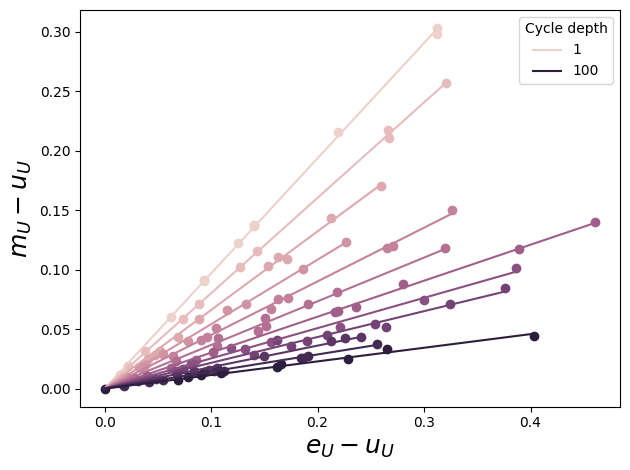

In [82]:
%matplotlib inline
from matplotlib import pyplot as plt

# Color by cycle depth
import seaborn as sns

colors = sns.cubehelix_palette(n_colors=len(cycle_depths))
colors = {k: colors[i] for i, k in enumerate(cycle_depths)}

_lines = []


def per_cycle_depth(df):
    fid_lsq = df['numerator'].sum() / df['denominator'].sum()

    cycle_depth = df.name
    xx = np.linspace(0, df['x'].max())
    (l,) = plt.plot(xx, fid_lsq * xx, color=colors[cycle_depth])
    plt.scatter(df['x'], df['y'], color=colors[cycle_depth])

    global _lines
    _lines += [l]  # for legend
    return pd.Series({'fidelity': fid_lsq})


fids = df.groupby('cycle_depth').apply(per_cycle_depth).reset_index()
plt.xlabel(r'$e_U - u_U$', fontsize=18)
plt.ylabel(r'$m_U - u_U$', fontsize=18)
_lines = np.asarray(_lines)
plt.legend(_lines[[0, -1]], cycle_depths[[0, -1]], loc='best', title='Cycle depth')
plt.tight_layout()


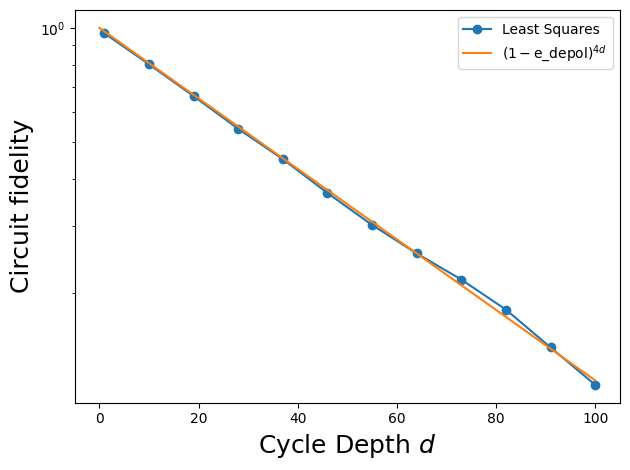

In [83]:
plt.plot(fids['cycle_depth'], fids['fidelity'], marker='o', label='Least Squares')

xx = np.linspace(0, fids['cycle_depth'].max())

# In XEB, we extract the depolarizing fidelity, which is
# related to (but not equal to) the Pauli error.
# For the latter, an error involves doing X, Y, or Z with E_PAULI/3
# but for the former, an error involves doing I, X, Y, or Z with e_depol/4
e_depol = E_PAULI / (1 - 1 / DIM**2)

# The additional factor of four in the exponent is because each layer
# involves two moments of two qubits (so each layer has four applications
# of a single-qubit single-moment depolarizing channel).
plt.plot(xx, (1 - e_depol) ** (4 * xx), label=r'$(1-\mathrm{e\_depol})^{4d}$')

plt.ylabel('Circuit fidelity', fontsize=18)
plt.xlabel('Cycle Depth $d$', fontsize=18)
plt.legend(loc='best')
plt.yscale('log')
plt.tight_layout()

In [84]:
from cirq.experiments.xeb_fitting import fit_exponential_decays

# Ordinarily, we'd use this function to fit curves for multiple pairs.
# We add our qubit pair as a column.
fids['pair'] = [(q0, q1)] * len(fids)

fit_df = fit_exponential_decays(fids)
fit_row = fit_df.iloc[0]
print(f"Noise model fidelity: {(1-e_depol)**4:.3e}")
print(f"XEB layer fidelity:   {fit_row['layer_fid']:.3e} +- {fit_row['layer_fid_std']:.2e}")

Noise model fidelity: 9.788e-01
XEB layer fidelity:   9.790e-01 +- 1.22e-04


Due to noise, fidelity decays with the circuit depth. So, we assume that for each layer has the same fidelity, so for the whole circuit $F_{circuit} \approx F_{layer}^d$, where $d$ is the depth/cycles. 

$F_{layer} = 1- \epsilon$, then $F_{circuit}(d) = (1-\epsilon)^d \approx e^{-\epsilon d}$

### Coherent vs incoherent Error with XEB

Summary: XEB fidelity decays exponentially for incoherent noise, but for coherent data has more struture. 

In [ ]:
print("Creating random circuit form a library and using sqrt_iSWAP as EG")
from cirq.experiments import random_quantum_circuit_generation as rqcg

RANDOM_SEED = np.random.RandomState(53)

circuit_library = rqcg.generate_library_of_2q_circuits(
    n_library_circuits=20, two_qubit_gate=cirq.SQRT_ISWAP, random_state=RANDOM_SEED
)
max_depth = 100
cycle_depths = np.arange(3, max_depth, 20)

Creating random circuit form a library and using iSWAP as EG


To create coherent noise, instead of the intended $\sqrt{iSWAP}$, we change to a $PhasedFSim(\theta = -\pi/4, \delta\phi)$

In [ ]:
# build sqrt_iswap gate from a phased fsim gate
sqrt_iswap_as_phased_fsim = cirq.PhasedFSimGate.from_fsim_rz(
    theta=-np.pi / 4, phi=0, rz_angles_before=(0, 0), rz_angles_after=(0, 0)
)

# check that the unitaries are the same
np.testing.assert_allclose(
    cirq.unitary(sqrt_iswap_as_phased_fsim), cirq.unitary(cirq.SQRT_ISWAP), atol=1e-8
)

from collections import defaultdict

#range for the \delta\phi
phi_angles = defaultdict(lambda: RANDOM_SEED.uniform(low=0, high=2 / 16 * np.pi))


def _sub_iswap(op):
    if op.gate == cirq.SQRT_ISWAP:
        # add coherent error to the phi angle while creating a sqrt iswap gate
        perturbed_sqrt_iswap = cirq.PhasedFSimGate.from_fsim_rz(
            theta=-np.pi / 4,
            phi=phi_angles[op.qubits],
            rz_angles_before=(0, 0),
            rz_angles_after=(0, 0),
        )

        return perturbed_sqrt_iswap.on(*op.qubits)
    return op

In [89]:
print("Creating the 'fused' model which incorporates all the noises")
from typing import Sequence


class FusedNoiseModel(cirq.NoiseModel):
    """A noise model that applies other noise models in sequence"""

    def __init__(self, models: Sequence[cirq.NoiseModel]):
        self.models = models

    def noisy_moment(self, moment: 'cirq.Moment', system_qubits: Sequence['cirq.Qid']):
        """Produce a list of moments by applying each model in sequence to the available moments"""

        moments = [moment]
        for model in self.models:
            new_moments = []
            for moment in moments:
                ret = model.noisy_moment(moment, system_qubits)
                # handle constituent noise models returning lists of or singleton moments
                new_moments.extend([ret] if isinstance(ret, cirq.Moment) else ret)
            moments = new_moments
        return moments

Creating the 'fused' model which incorporates all the noises


In [90]:
# create noise models
coherent_noise = cirq.devices.noise_model.GateSubstitutionNoiseModel(_sub_iswap)
incoherent_noise = cirq.ConstantQubitNoiseModel(cirq.depolarize(5e-3))
noiseless = None
fused_noise = FusedNoiseModel([coherent_noise, incoherent_noise])

# create samplers by passing noise models to simulator constructor
coherent_sampler = cirq.DensityMatrixSimulator(noise=coherent_noise)
incoherent_sampler = cirq.DensityMatrixSimulator(noise=incoherent_noise)
noiseless_sampler = cirq.DensityMatrixSimulator(noise=noiseless)
fused_sampler = cirq.DensityMatrixSimulator(noise=fused_noise)

# from here on out, all experiment steps will be performed on
#   samplers and their results in the following order.
samplers = [coherent_sampler, incoherent_sampler, noiseless_sampler, fused_sampler]
noise_titles = ['Coherent', 'Incoherent', 'Noiseless', 'Fused']
print("Finally, we have all four models: just coherent, just incoherent, both, and none")

Finally, we have all four models: just coherent, just incoherent, both, and none


Mocking a device


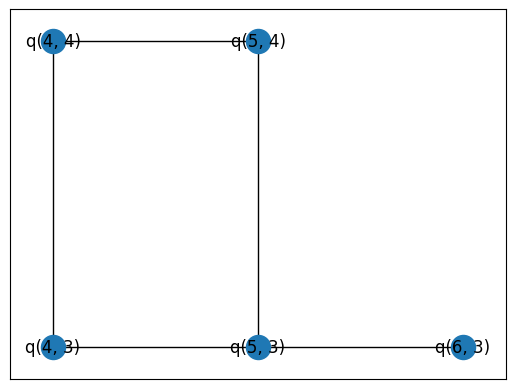

In [ ]:
print("Mocking a device")
import networkx as nx
import itertools

# a set of six example GridQubits
qubits = cirq.GridQubit.rect(3, 2, 4, 3)
# only use the first num_qubits many qubits
num_qubits = 5
qubits = qubits[:num_qubits]

# create graph from adjacent qubits
graph = nx.Graph((q1, q2) for (q1, q2) in itertools.combinations(qubits, 2) if q1.is_adjacent(q2))
pos = {q: (q.row, q.col) for q in qubits}
nx.draw_networkx(graph, pos=pos)


# Running XEB in parallel by identifing correctly the non-overlapping active pairs. 
# Ex: (q0,q1) cannot run in parallel to (q1,q2) but it can for (q2,q3)
combs_by_layer = rqcg.get_random_combinations_for_device(
    n_library_circuits=len(circuit_library),
    n_combinations=10,
    device_graph=graph,
    random_state=RANDOM_SEED,
)

In [94]:
import cirq.experiments.xeb_sampling as xeb_sampling
import cirq.experiments.xeb_fitting as xeb_fitting


# use the same circuit library, cycle depths, combinations by layer,
#   random seed and repetitions for both noise models' samplers.
def sample_df(sampler):
    return xeb_sampling.sample_2q_xeb_circuits(
        sampler=sampler,
        circuits=circuit_library,
        cycle_depths=cycle_depths,
        combinations_by_layer=combs_by_layer,
        shuffle=RANDOM_SEED,
        repetitions=1000,
    )


sampled_dfs = list(map(sample_df, samplers))

100%|██████████| 207/207 [00:40<00:00,  5.12it/s]


In [96]:
# use the same circuit library and cycle_depths for both
#   noise models' sampled data.
def estimate_fidelities(sampled_df):
    return xeb_fitting.benchmark_2q_xeb_fidelities(
        sampled_df=sampled_df, circuits=circuit_library, cycle_depths=cycle_depths
    )


circuit_fidelities = list(map(estimate_fidelities, sampled_dfs))


In [97]:
fitted_fidelities = list(map(xeb_fitting.fit_exponential_decays, circuit_fidelities))

Since the XEB calculates the fidelity of the whole circuit, we separe the EG in pair to have the effective fidelity of the pair. However, the work can be paralized since $q_0,q_1$ and $q_2,q_3$ are essentially two different circuits for example. 

C:\Users\edson\AppData\Local\Temp\ipykernel_34636\4251997075.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


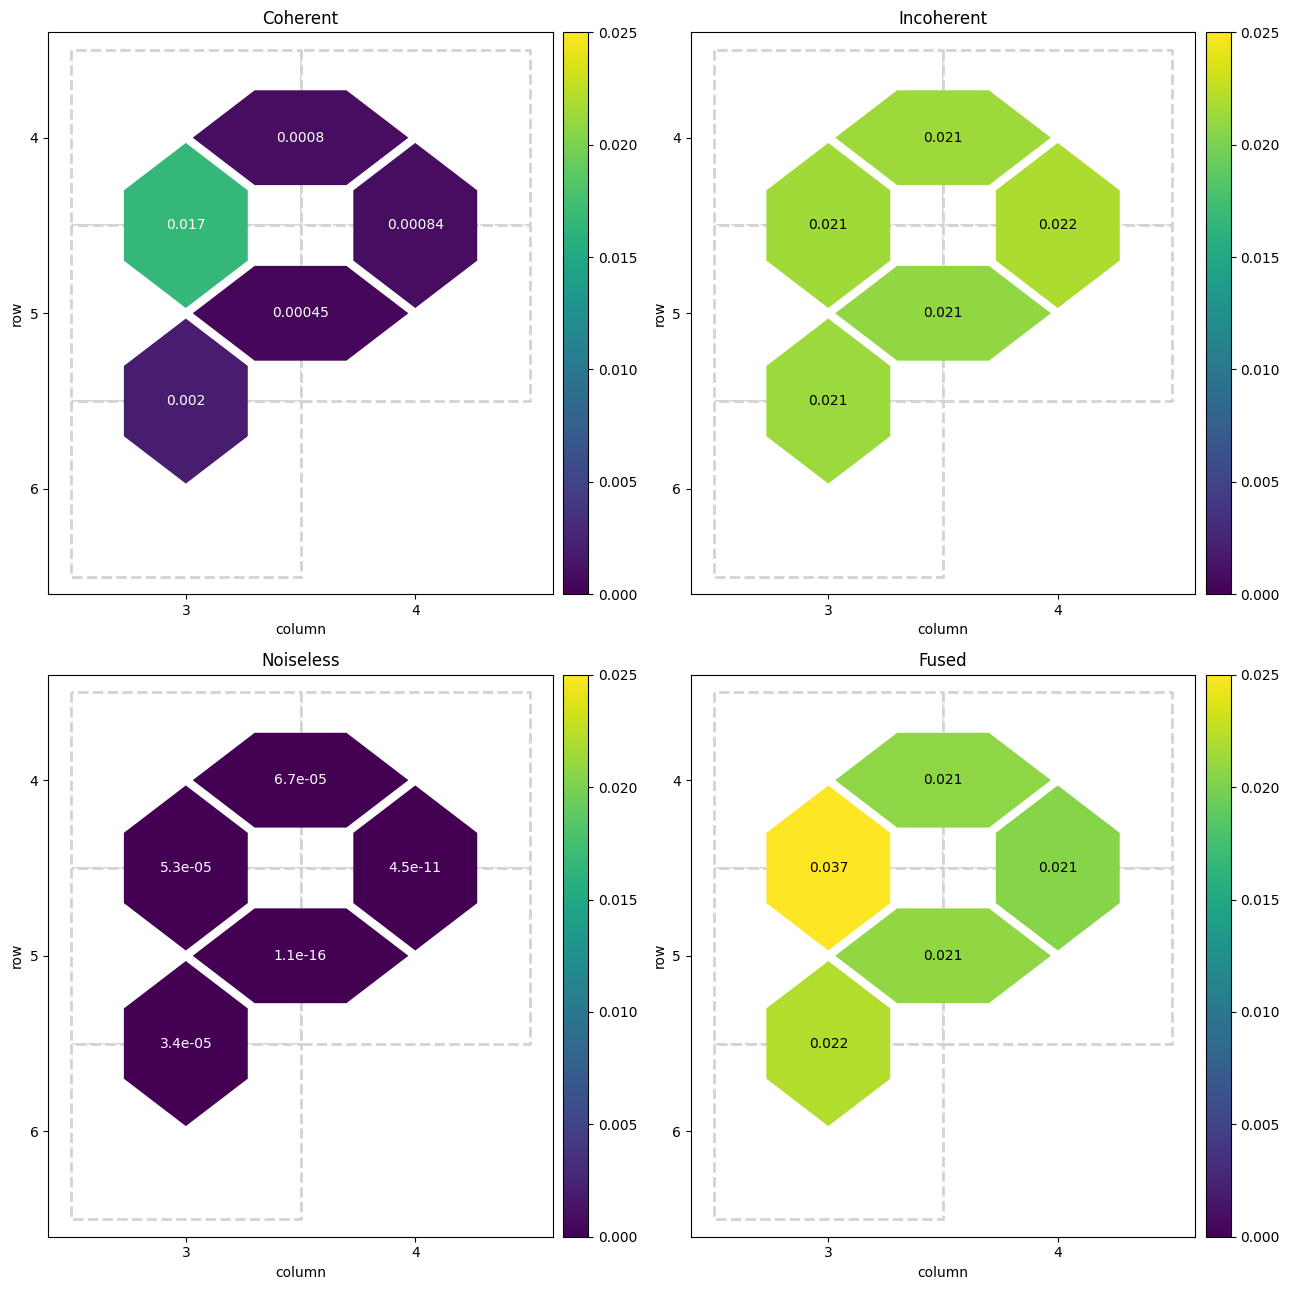

In [98]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for fidelities, ax, title in zip(fitted_fidelities, axes.flat, noise_titles):
    # pull out the by-layer/cycle fidelity and turn it into error with 1-fidelity.
    heatmap_data = {
        pair: (1.0 - layer_fid) for ((_, _, pair), layer_fid) in fidelities.layer_fid.items()
    }
    cirq.TwoQubitInteractionHeatmap(heatmap_data, vmin=0, vmax=0.025).plot(ax)

    ax.set_title(title)

fig.tight_layout()
fig.show()

The heatmap is useful for general perspetive of the fidelity, but the fidelity as a function of cycles tells us about the struture of the noise. 

C:\Users\edson\AppData\Local\Temp\ipykernel_34636\3588497853.py:74: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


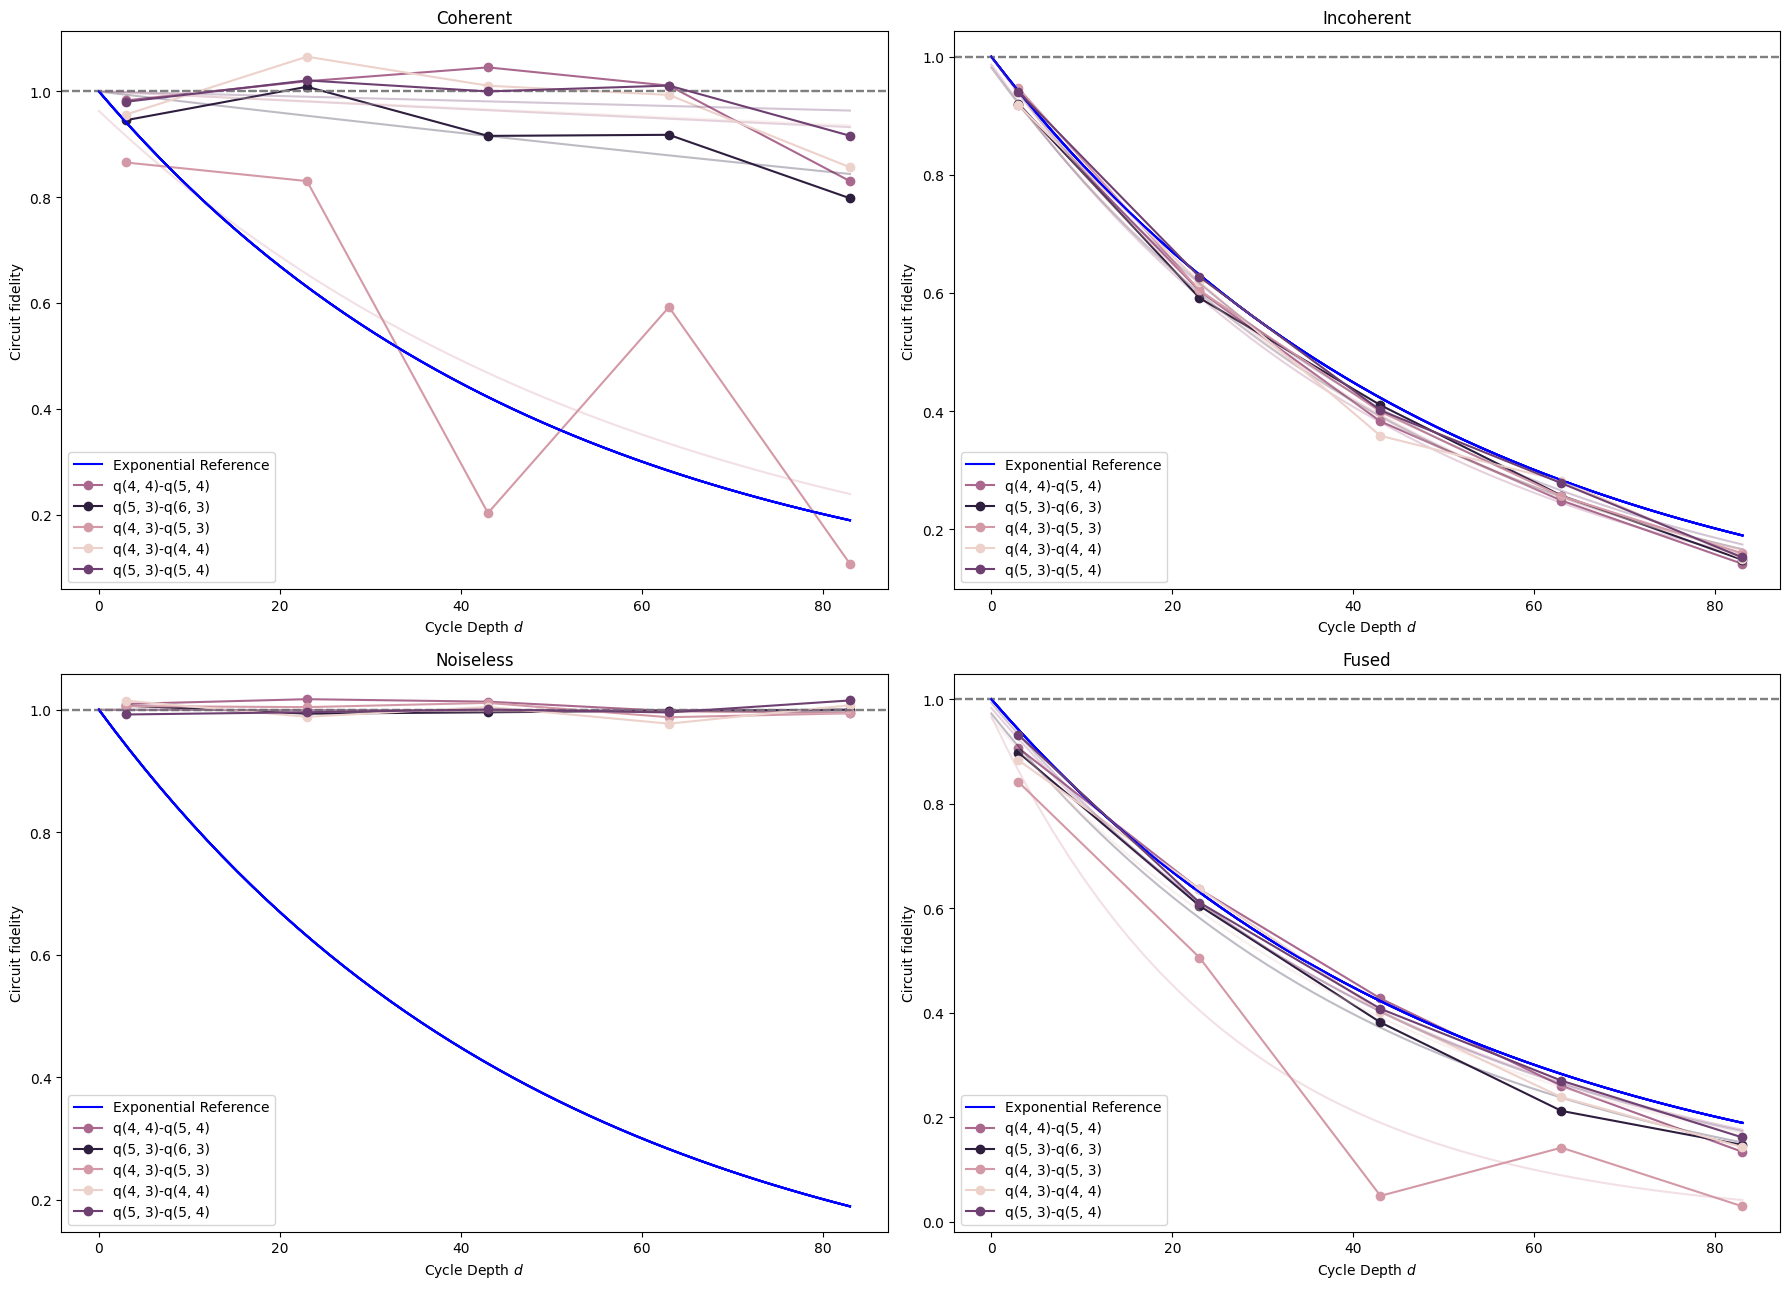

In [102]:
import seaborn as sns

# map colors to qubit pairs
colors = sns.cubehelix_palette(n_colors=graph.number_of_edges())
colors = dict(zip(graph.edges, colors))


def _p_gen(ax, rescale=False, decay=5e-3, color=None, colors=colors, label=None):
    """Create a _p function to graph circuit fidelities by layer.
    It encodes the visualization options:
    - rescale: rescale data under the exponential decay line to range [0,1].
    - decay: exponent defining the exponential decay reference line.
    - color: plot everything in given color, use by-qubit color map otherwise.
    - colors: the by-qubit color map.
    - label: label to give the data in the legend.
    """

    def _p(record):
        """For a row of a fidelity data frame, plot based on encoded options"""

        # pull fidelities from data frame row/record
        data = record.fidelities

        # plot horizontal at 1.0 fidelity
        ax.axhline(1, color='grey', ls='--')

        # compute exponential decay line from record parameters (a, layer_fid)
        # these were computed by previous fitting from fidelity data
        xx = np.linspace(0, record.cycle_depths.max())
        exp = xeb_fitting.exponential_decay(xx, a=record.a, layer_fid=record.layer_fid)

        # rescale data to expand area under exponential reference decay line
        # the range from zero to the reference line becomes the range [0, 1]
        # also plot that reference line in blue, which, once rescaled, is horizontal
        if rescale:
            data = data / ((1 - decay) ** (4 * record.cycle_depths))
            exp = exp / ((1 - decay) ** (4 * xx))
            ax.plot(xx, xx**0, label=r'Normalized Reference', color='blue')
        else:
            ax.plot(xx, (1 - decay) ** (4 * xx), label=r'Exponential Reference', color='blue')

        _, _, pair = record.name
        q0, q1 = pair
        # use qubit pair to color map if color is not supplied, else just use color
        plot_color = colors[pair] if color is None else color
        # use qubit pair as label if not supplied, else just use label
        plot_label = f'{q0}-{q1}' if label is None else label

        # plot the data with the selected color and label
        ax.plot(record.cycle_depths, data, 'o-', color=plot_color, label=plot_label)
        # also plot the data-fitted exponential line
        ax.plot(xx, exp, color=plot_color, alpha=0.3)

    return _p


def extras(ax, title):
    """Add labels, title and legend to an axis"""

    ax.set_ylabel('Circuit fidelity')
    ax.set_xlabel('Cycle Depth $d$')
    ax.set_title(title)
    # create a legend while making sure the handles are unique
    handles, labels = ax.get_legend_handles_labels()
    legend_items = dict(zip(labels, handles))
    ax.legend(legend_items.values(), legend_items.keys(), loc='best')

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
for fidelities, ax, title in zip(fitted_fidelities, axes.flat, noise_titles):
    fidelities.apply(_p_gen(ax), axis=1)
    extras(ax, title)

fig.tight_layout()
fig.show()



Here we can the struture of the coherent noise. Incoherent noise gives us the expected exponential decay. When both are added, we can see the deviation from the exponential coming form the coherent noise.

Now, we focus just on the fused data using a rescaling from the known incoherent error of $5e-3$. $F_{rescaled}(d) = \frac{F_{fused}(d)}{(1-p)^{4d}}$

C:\Users\edson\AppData\Local\Temp\ipykernel_34636\2423165333.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


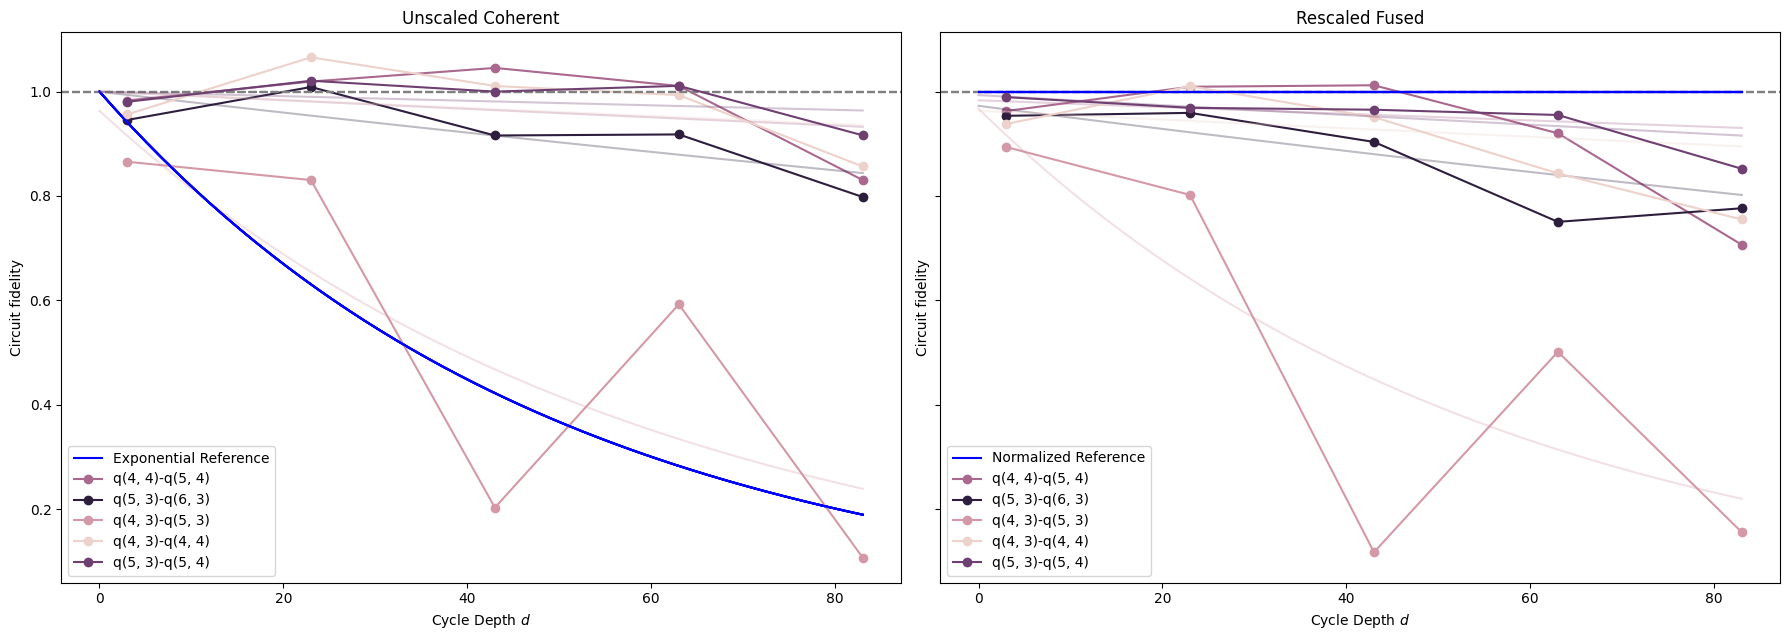

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), sharey=True)
two_fidelities = [fitted_fidelities[0], fitted_fidelities[3]]
titles = [r'Unscaled Coherent', r'Rescaled Fused']
for fidelities, rescale, ax, title in zip(two_fidelities, [False, True], axes.flat, titles):
    fidelities.apply(_p_gen(ax, rescale=rescale), axis=1)
    extras(ax, title)

fig.tight_layout()
fig.show()

Comparing just the coherent graph and the rescaled fused data, we check that both are really similar. However not identical. This feature showcase that there is a intrinsic interaction between the errors. 

Now, we use a classical optimizer to find the correct parameter to approximate the actual two-qubit gate used. The optimizer is going to find from the PhsedFSim which parameter closely replicate the observed fidelity data.

In real hardware, there are more kinds of coherent errors. For those, they will confund the parameter optimization procedure. 

In [104]:
import multiprocessing

pool = multiprocessing.get_context('spawn').Pool()

# Set which angles to characterize (all)
options = xeb_fitting.SqrtISwapXEBOptions(
    characterize_theta=False,
    characterize_zeta=False,
    characterize_chi=False,
    characterize_gamma=False,
    characterize_phi=True,
)
# Parameterize the sqrt(iswap)s in circuit library
pcircuits = [xeb_fitting.parameterize_circuit(circuit, options) for circuit in circuit_library]


def characterization_result(sampled_df):
    # Run the characterization loop
    return xeb_fitting.characterize_phased_fsim_parameters_with_xeb_by_pair(
        sampled_df,
        pcircuits,
        cycle_depths,
        options,
        pool=pool,
        # ease tolerance so it converges faster:
        fatol=1e-2,
        xatol=1e-2,
    )

print("Definining the optimizatio and only making phi as a parameter search")

Definining the optimizatio and only making phi as a parameter search


We run the optimizer

In [105]:
characterization_results = list(map(characterization_result, sampled_dfs))

In [106]:
characterization_results[0].final_params

{(cirq.GridQubit(4, 3),
  cirq.GridQubit(5, 3)): {'phi': np.float64(0.41875000000000007)},
 (cirq.GridQubit(4, 4),
  cirq.GridQubit(5, 4)): {'phi': np.float64(0.10625000000000001)},
 (cirq.GridQubit(5, 3), cirq.GridQubit(6, 3)): {'phi': np.float64(0.13125)},
 (cirq.GridQubit(5, 3), cirq.GridQubit(5, 4)): {'phi': np.float64(0.1)},
 (cirq.GridQubit(4, 3), cirq.GridQubit(4, 4)): {'phi': np.float64(0.06875)}}

In [107]:
for qubits, phi in phi_angles.items():
    print(qubits, phi)

(cirq.GridQubit(4, 3), cirq.GridQubit(5, 3)) 0.3799064806542888
(cirq.GridQubit(4, 4), cirq.GridQubit(5, 4)) 0.08119129771673056
(cirq.GridQubit(5, 3), cirq.GridQubit(6, 3)) 0.14120271164445705
(cirq.GridQubit(5, 3), cirq.GridQubit(5, 4)) 0.06671132621887749
(cirq.GridQubit(4, 3), cirq.GridQubit(4, 4)) 0.09041395290935288


C:\Users\edson\AppData\Local\Temp\ipykernel_34636\2051263692.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


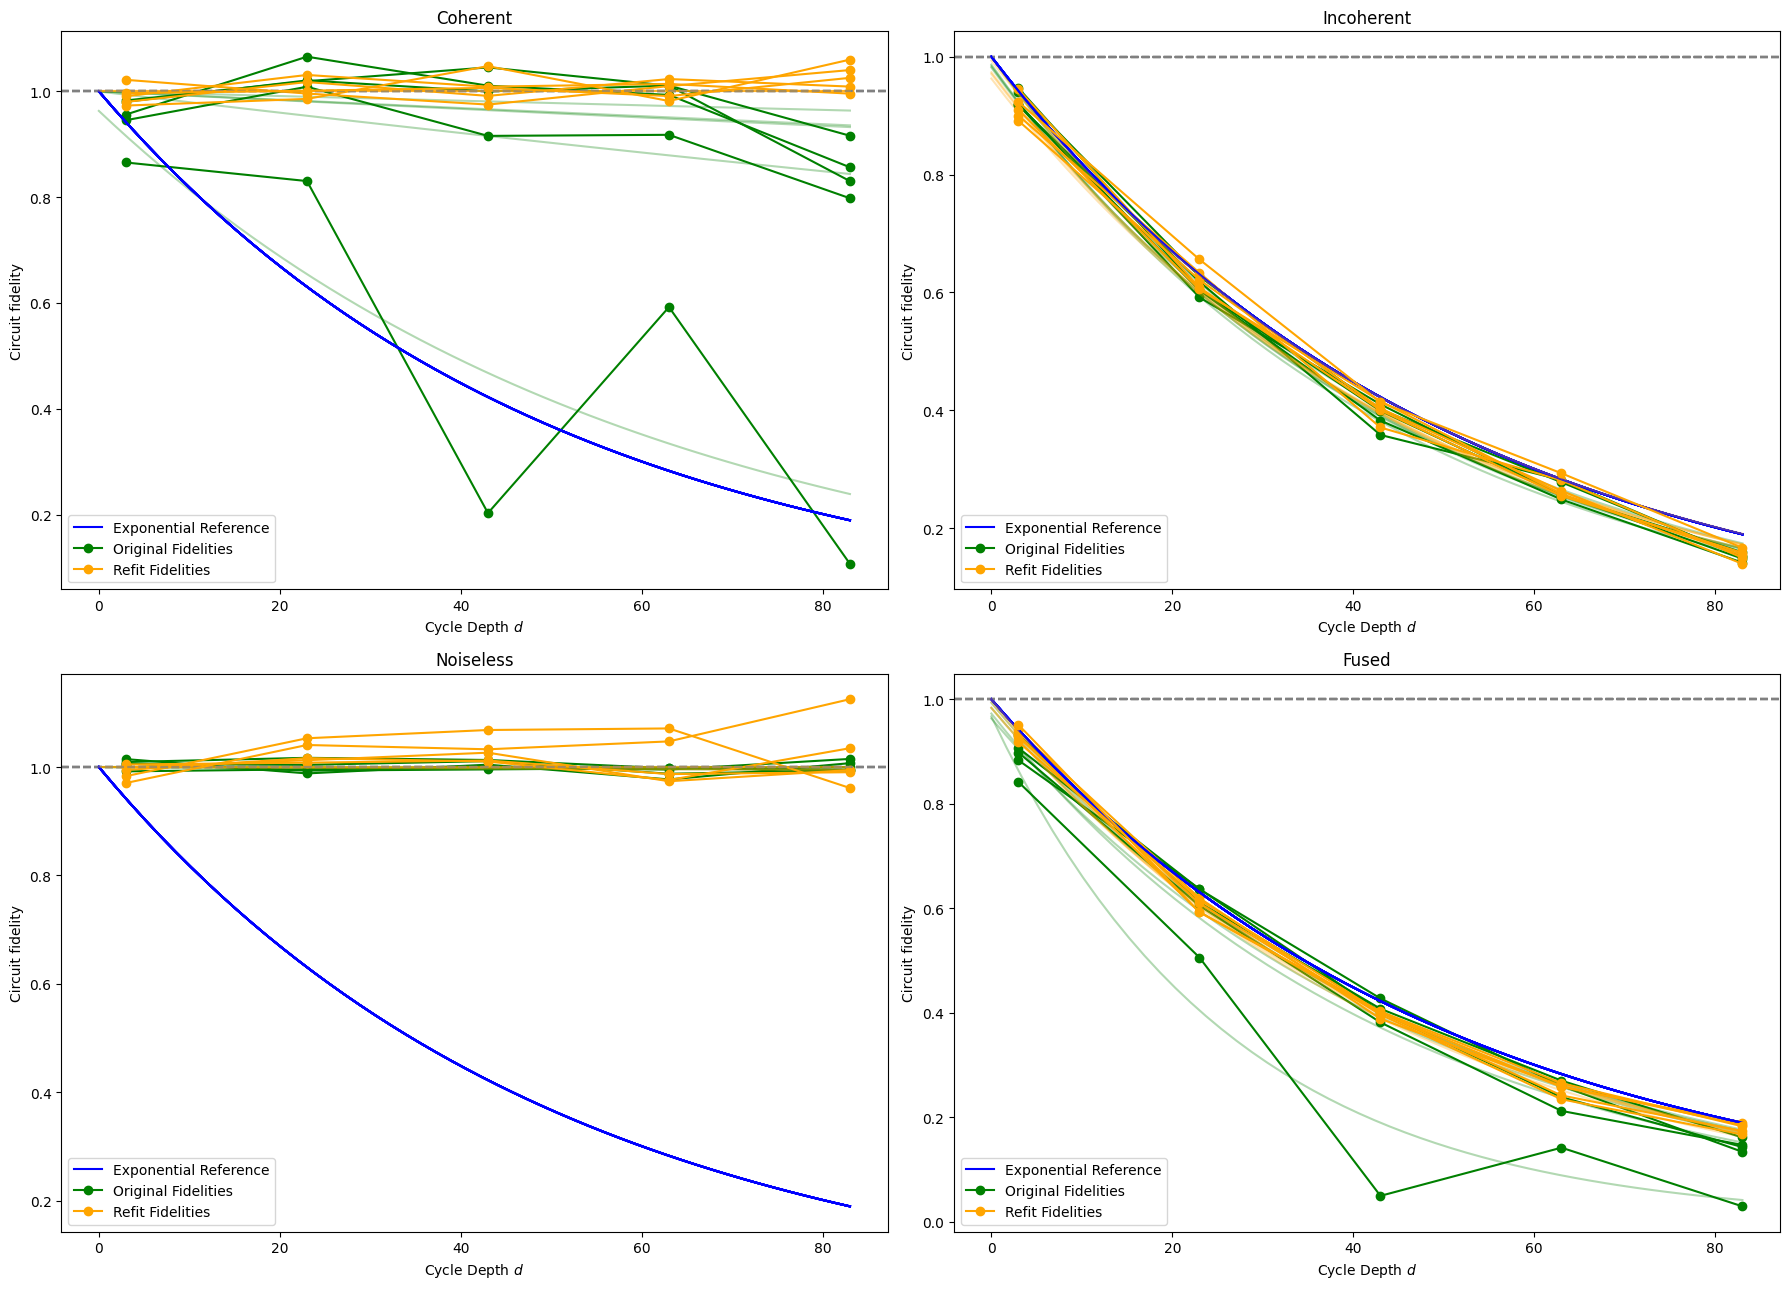

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
result_dfs = list(map(lambda x: x.fidelities_df, characterization_results))
result_fidelities = list(map(xeb_fitting.fit_exponential_decays, result_dfs))
before_dfs = fitted_fidelities
after_dfs = result_fidelities
for before_df, after_df, ax, title in zip(before_dfs, after_dfs, axes.flat, noise_titles):
    before_df.apply(_p_gen(ax, color='green', label=r'Original Fidelities'), axis=1)
    after_df.apply(_p_gen(ax, color='orange', label=r'Refit Fidelities'), axis=1)
    extras(ax, title)

fig.tight_layout()
fig.show()

By identifying those parameters, it idicates hardware re-calibration or a compensation must be performed. 

C:\Users\edson\AppData\Local\Temp\ipykernel_34636\27413407.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


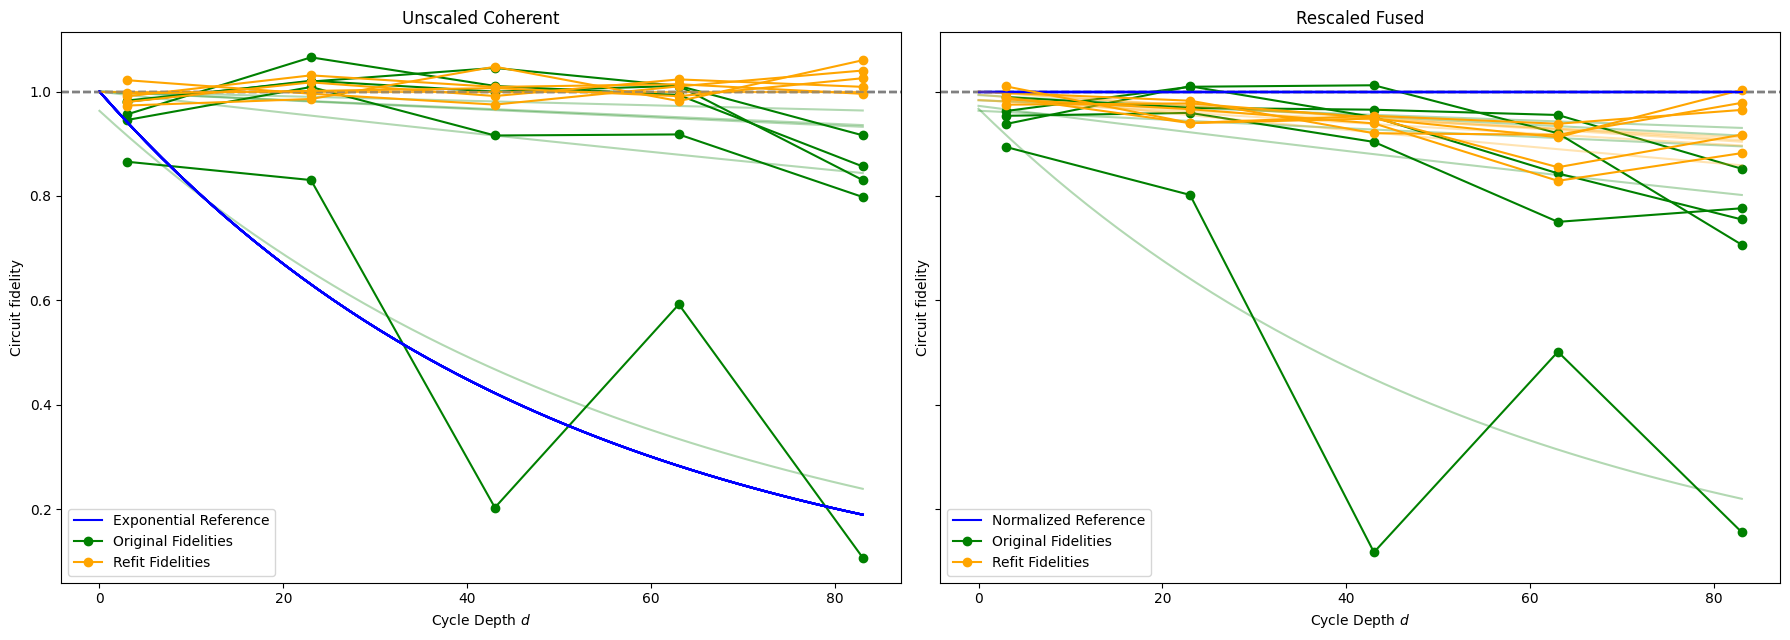

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), sharey=True)
before_dfs = [fitted_fidelities[0], fitted_fidelities[3]]
after_dfs = [result_fidelities[0], result_fidelities[3]]
titles = [r'Unscaled Coherent', r'Rescaled Fused']
for before_df, after_df, ax, title, rescale in zip(
    before_dfs, after_dfs, axes.flat, titles, [False, True]
):
    before_df.apply(
        _p_gen(ax, color='green', label=r'Original Fidelities', rescale=rescale), axis=1
    )
    after_df.apply(_p_gen(ax, color='orange', label=r'Refit Fidelities', rescale=rescale), axis=1)
    extras(ax, title)

fig.tight_layout()
fig.show()

## Device qubit Handling 

In [36]:

processor_id = "willow_pink"

noise_props = cg.engine.load_device_noise_properties(processor_id)
device = cg.engine.create_device_from_processor_id(processor_id)

print(device)

print("Single-qubit gate types:")
print(noise_props.single_qubit_gates())

print("Two-qubit gate types:")
print(noise_props.two_qubit_gates())

print("Number of gate Pauli error entries:", len(noise_props.gate_pauli_errors))
print("Number of FSim error entries:", len(noise_props.fsim_errors))
print("Number of readout error entries:", len(noise_props.readout_errors))


                                                        (0, 6)────(0, 7)────(0, 8)
                                                        │         │         │
                                                        │         │         │
                                              (1, 5)────(1, 6)────(1, 7)────(1, 8)
                                              │         │         │         │
                                              │         │         │         │
                                    (2, 4)────(2, 5)────(2, 6)────(2, 7)────(2, 8)────(2, 9)────(2, 10)
                                    │         │         │         │         │         │         │
                                    │         │         │         │         │         │         │
                           (3, 3)───(3, 4)────(3, 5)────(3, 6)────(3, 7)────(3, 8)────(3, 9)────(3, 10)
                           │        │         │         │         │         │         │         │
                    

{<class 'cirq.ops.common_channels.ResetChannel'>, <class 'cirq.ops.measurement_gate.MeasurementGate'>, <class 'cirq.ops.phased_x_z_gate.PhasedXZGate'>, <class 'cirq.ops.common_gates.ZPowGate'>}


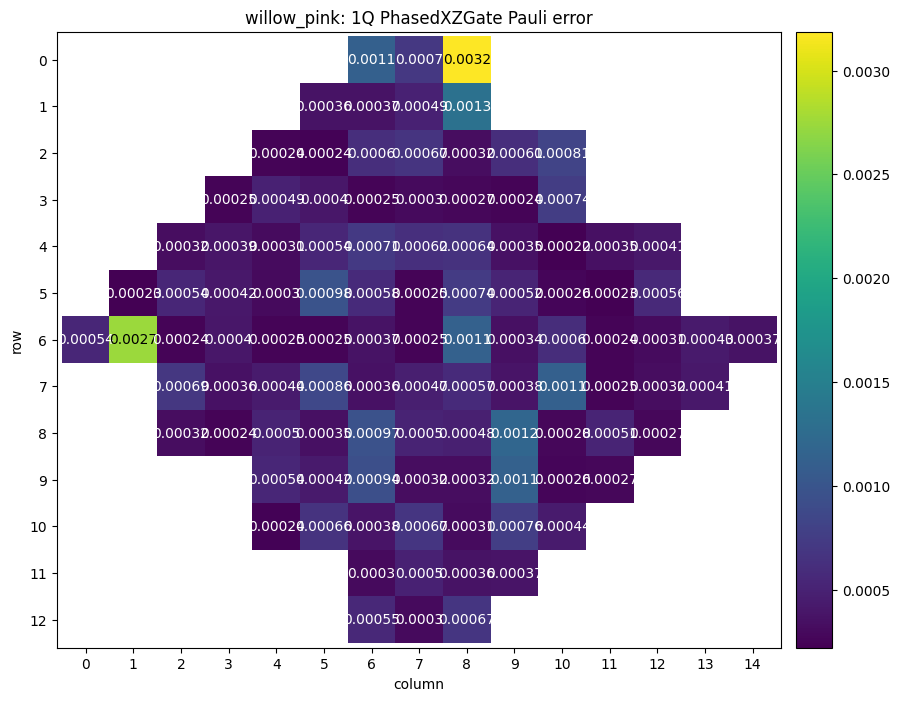

In [39]:
one_qubit_gates = noise_props.single_qubit_gates()
print(one_qubit_gates)
gate = cirq.PhasedXZGate

measures_1q = {}

for op_id, pauli_error in noise_props.gate_pauli_errors.items():
    if op_id.gate_type == gate and len(op_id.qubits) == 1:
        q = op_id.qubits[0]
        measures_1q[q] = pauli_error

plt.figure(figsize=(10, 8))
ax = plt.gca()
ax.set_title(f"{processor_id}: 1Q {gate.__name__} Pauli error")
cirq.Heatmap(measures_1q).plot(ax)
plt.show()

Stochastic Pauli errors in two-qubit gate: coupler performance

{<class 'cirq.ops.swap_gates.ISwapPowGate'>, <class 'cirq.ops.fsim_gate.FSimGate'>, <class 'cirq.ops.common_gates.CZPowGate'>, <class 'cirq_google.ops.sycamore_gate.SycamoreGate'>, <class 'cirq.ops.fsim_gate.PhasedFSimGate'>}


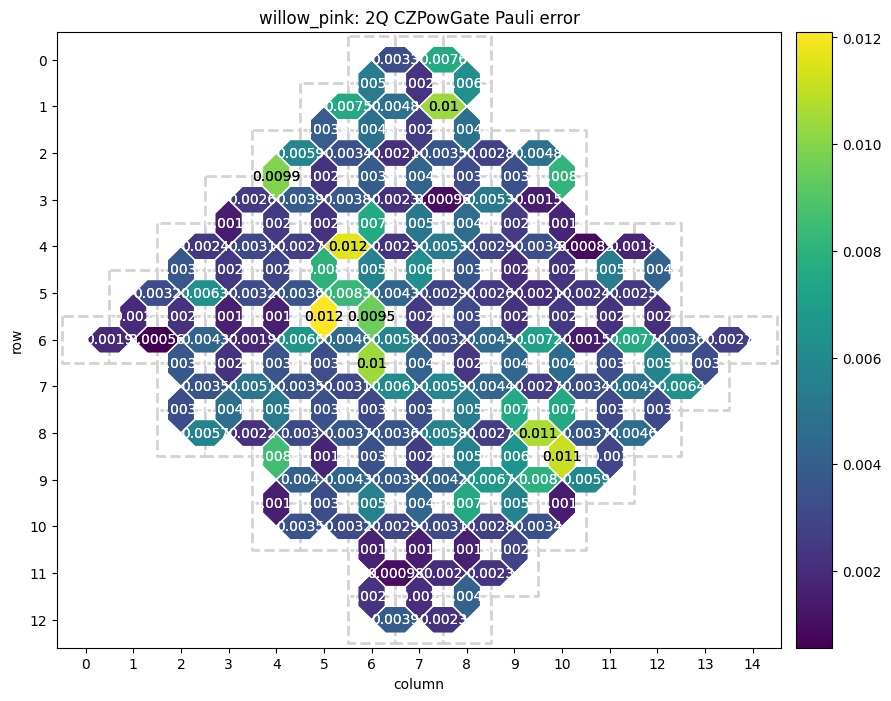

In [41]:
two_qubit_gates = noise_props.two_qubit_gates()
print(two_qubit_gates)

for gate in two_qubit_gates:
    measures_2q = {}

    for op_id, pauli_error in noise_props.gate_pauli_errors.items():
        if op_id.gate_type == gate and len(op_id.qubits) == 2:
            measures_2q[op_id.qubits] = pauli_error

    if len(measures_2q) == 0:
        continue

    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    ax.set_title(f"{processor_id}: 2Q {gate.__name__} Pauli error")
    cirq.TwoQubitInteractionHeatmap(measures_2q).plot(ax)
    plt.show()

FSim error for coherent two-qubit error

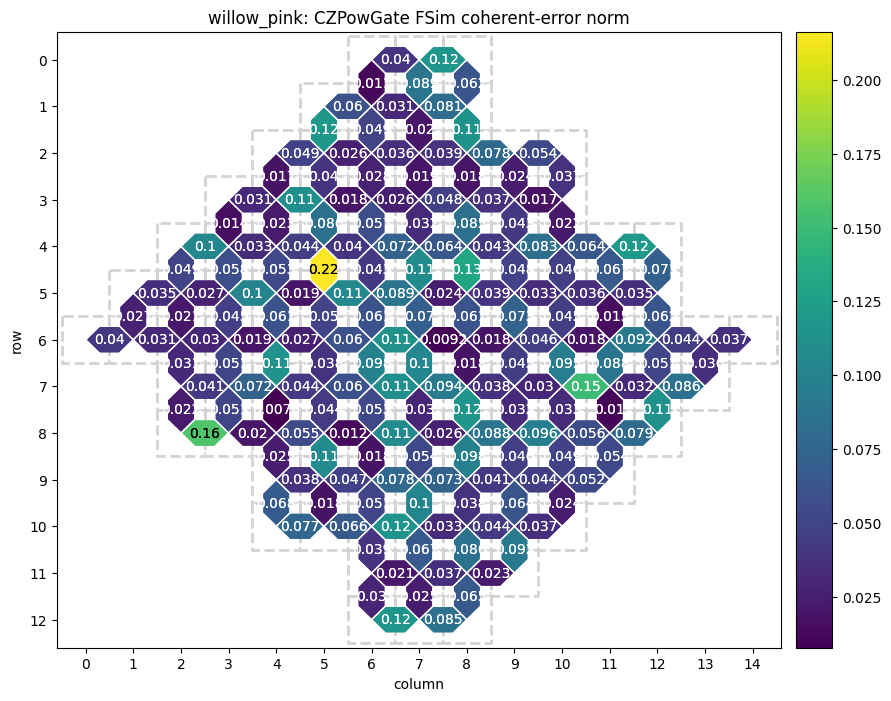

In [42]:
def fsim_error_norm(fsim_gate):
    vals = []

    for name in ["theta", "phi", "zeta", "chi", "gamma"]:
        if hasattr(fsim_gate, name):
            v = getattr(fsim_gate, name)
            if v is not None:
                vals.append(float(v))

    if len(vals) == 0:
        return np.nan

    return np.linalg.norm(vals)


for gate in noise_props.two_qubit_gates():
    measures_fsim = {}

    for op_id, fsim_refit_gate in noise_props.fsim_errors.items():
        if op_id.gate_type == gate and len(op_id.qubits) == 2:
            measures_fsim[op_id.qubits] = fsim_error_norm(fsim_refit_gate)

    if len(measures_fsim) == 0:
        continue

    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    ax.set_title(f"{processor_id}: {gate.__name__} FSim coherent-error norm")
    cirq.TwoQubitInteractionHeatmap(measures_fsim).plot(ax)
    plt.show()

Readout error

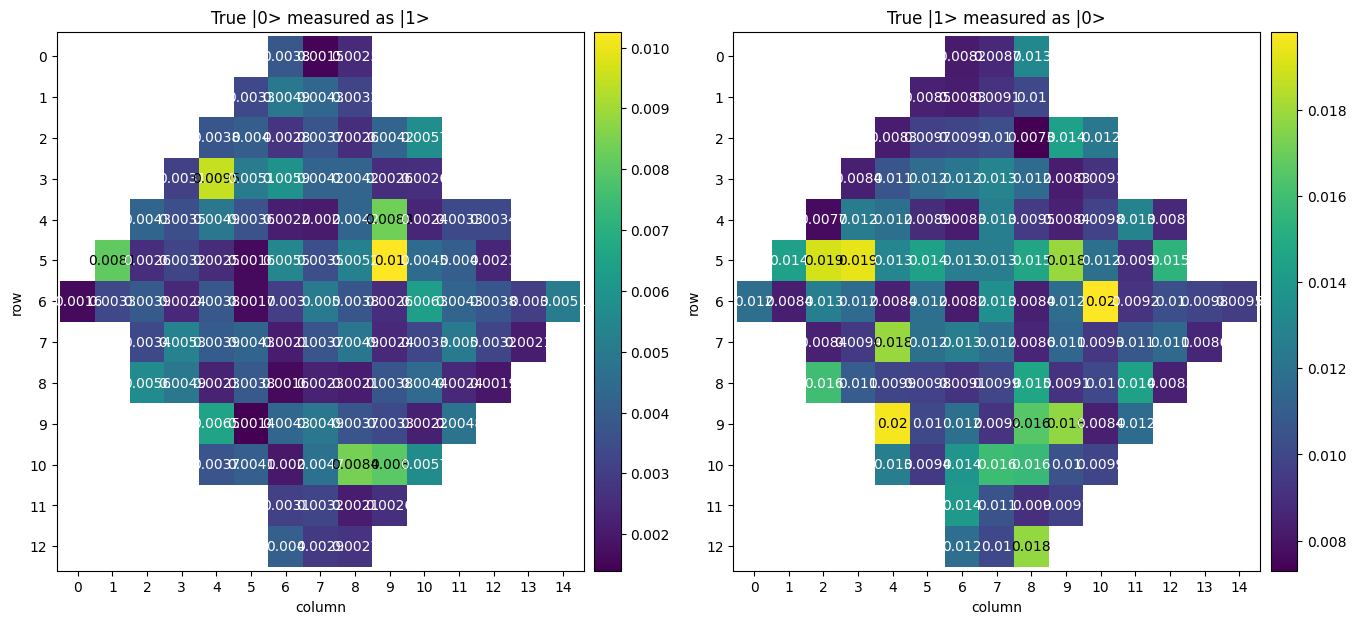

In [43]:
readout_0_to_1 = {}
readout_1_to_0 = {}

for q, readout_error in noise_props.readout_errors.items():
    readout_0_to_1[q] = readout_error[0]
    readout_1_to_0[q] = readout_error[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].set_title("True |0> measured as |1>")
cirq.Heatmap(readout_0_to_1).plot(axes[0])

axes[1].set_title("True |1> measured as |0>")
cirq.Heatmap(readout_1_to_0).plot(axes[1])

plt.show()

score = (
    10 * qm_readout_error
    + 1 * average_1q_error
    + 5 * average_2q_pauli_error
    + 5 * average_fsim_error
) for a measurement qubit

score = (
    2 * qm_readout_error
    + average_1q_error
    + average_2q_pauli_error
    + average_fsim_error
) for a butterfly qubit



Creating a noise model from Willow properties

In [ ]:
noise_model = cg.NoiseModelFromGoogleNoiseProperties(noise_props)
import qsimcirq
sim = qsimcirq.QSimSimulator(noise=noise_model) #importing the model simulator